In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

# Loading and Preprocessing

In [2]:
df = pd.read_csv('CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.tail()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


In [4]:
df.shape

(205, 26)

In [5]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [7]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [8]:
df[df.duplicated()]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


In [9]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

##### Initial Observation:
Dataset contains 205 rows and 26 columns.
No missing values in any columns. No duplicated rows.
There are non numerical data, so encoding will be required.
Also there are some unrelevent columns for the delivery time prediction which can be removed.

### Handling Outliers

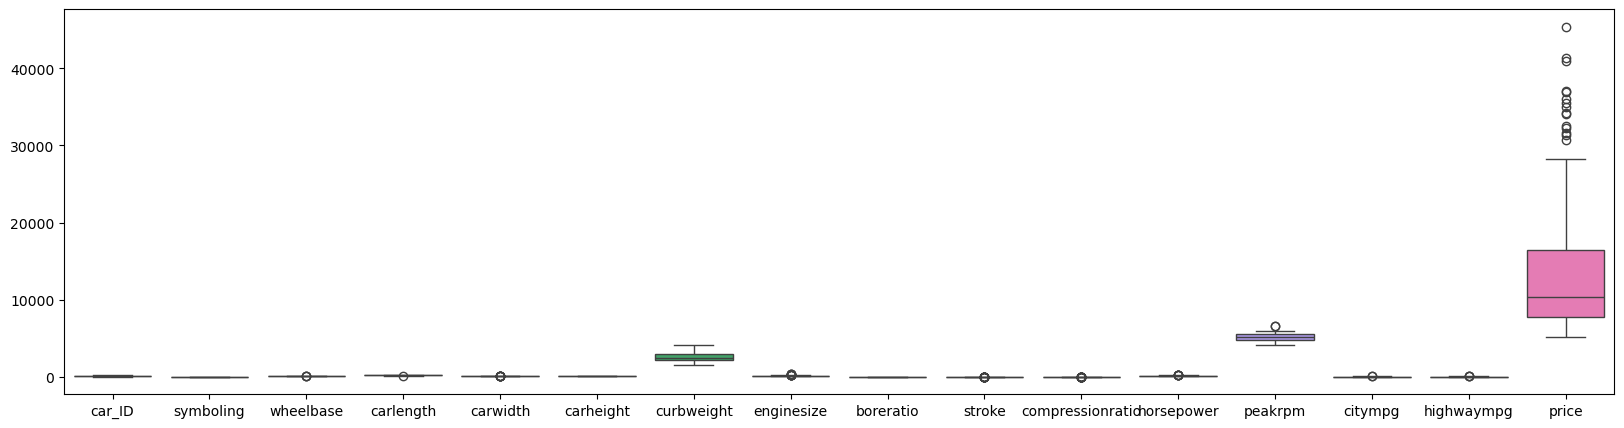

In [10]:
plt.figure(figsize=(20, 5))
sns.boxplot(df)
plt.show()

There is outliers in wheelbase, carlength, carwidth, enginesize, stroke, compressionratio, horsepower, peakrpm, citympg, highwaympg.

array([[<Axes: title={'center': 'car_ID'}>,
        <Axes: title={'center': 'symboling'}>,
        <Axes: title={'center': 'wheelbase'}>,
        <Axes: title={'center': 'carlength'}>],
       [<Axes: title={'center': 'carwidth'}>,
        <Axes: title={'center': 'carheight'}>,
        <Axes: title={'center': 'curbweight'}>,
        <Axes: title={'center': 'enginesize'}>],
       [<Axes: title={'center': 'boreratio'}>,
        <Axes: title={'center': 'stroke'}>,
        <Axes: title={'center': 'compressionratio'}>,
        <Axes: title={'center': 'horsepower'}>],
       [<Axes: title={'center': 'peakrpm'}>,
        <Axes: title={'center': 'citympg'}>,
        <Axes: title={'center': 'highwaympg'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

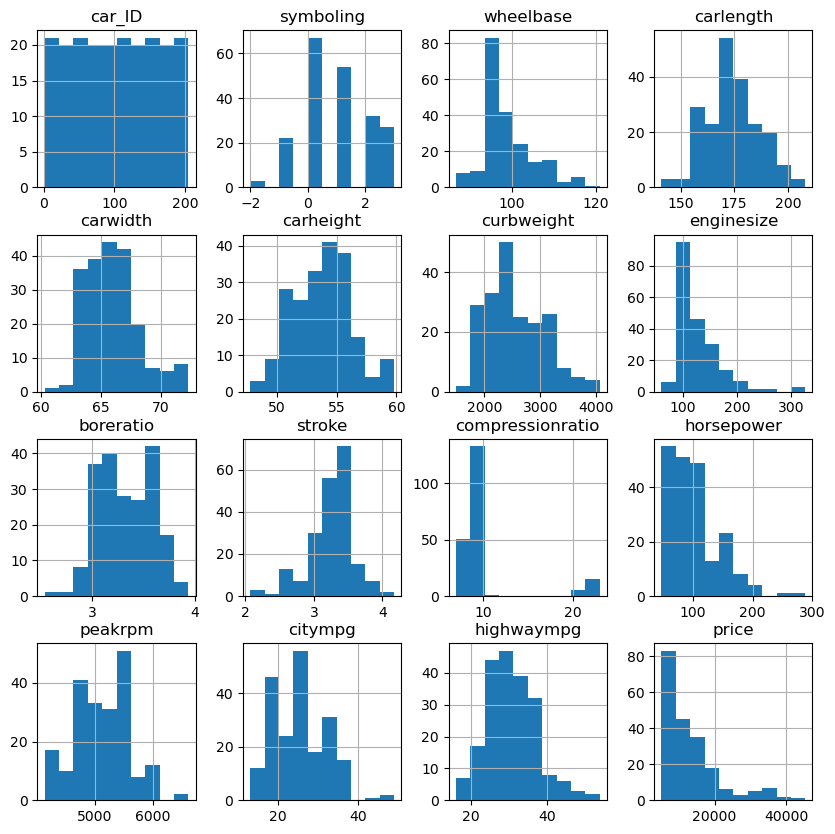

In [11]:
df.hist(figsize=(10, 10))

In [12]:
df['fueltype'].unique()

array(['gas', 'diesel'], dtype=object)

Outliers shown is with the difference in the values for gas and diesel fueltype cars. So these can't be considered as outliers.

In [13]:
df['fueltype'].value_counts()

fueltype
gas       185
diesel     20
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Gas vs Diesel Fuel Types')

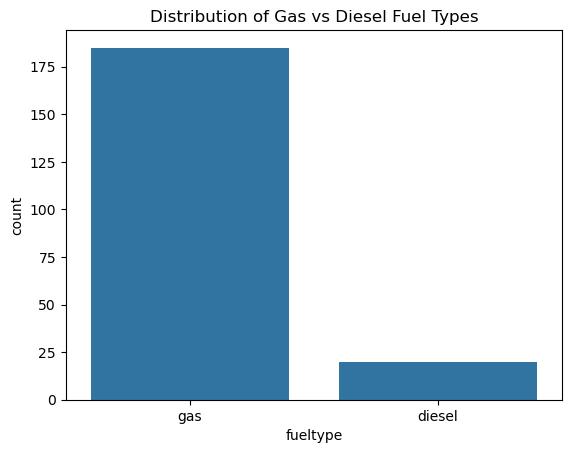

In [14]:
sns.countplot(x='fueltype', data=df)
plt.title('Distribution of Gas vs Diesel Fuel Types')

### Feature Engineering

In [15]:
df = df.drop(columns=['car_ID', 'CarName'])

In [16]:
df.dtypes

symboling             int64
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

**Ordinal Encoding the fueltype**

In [17]:
df['fueltype'].unique()

array(['gas', 'diesel'], dtype=object)

In [18]:
fueltype_map = {'gas' : 0, 'diesel' : 1}
df['fueltype'] = df['fueltype'].map(fueltype_map)
df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,0,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,0,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,0,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,0,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,0,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [19]:
df['fueltype'].unique()

array([0, 1])

**Ordinal Encoding the aspiration**

In [20]:
df['aspiration'].unique()

array(['std', 'turbo'], dtype=object)

In [21]:
aspiration_map = {'std' : 0, 'turbo' : 1}
df['aspiration'] = df['aspiration'].map(aspiration_map)

In [22]:
df['aspiration'].unique()

array([0, 1])

**Ordinal Encoding the doornumber**

In [23]:
df['doornumber'].unique()

array(['two', 'four'], dtype=object)

In [24]:
doornumber_map = {'two' : 0, 'four' : 1}
df['doornumber'] = df['doornumber'].map(doornumber_map)

In [25]:
df['doornumber'].unique()

array([0, 1])

**Label Encoding the carbody**

In [26]:
df['carbody'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [27]:
le_carbody = LabelEncoder()
df['carbody'] = le_carbody.fit_transform(df['carbody'])

In [28]:
df['carbody'].unique()

array([0, 2, 3, 4, 1])

**Label Encoding the drivewheel**

In [29]:
df['drivewheel'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [30]:
le_drivewheel = LabelEncoder()
df['drivewheel'] = le_drivewheel.fit_transform(df['drivewheel'])

In [31]:
df['drivewheel'].unique()

array([2, 1, 0])

**Ordinal Encoding the enginelocation**

In [32]:
df['enginelocation'].unique()

array(['front', 'rear'], dtype=object)

In [33]:
enginelocation_map = {'front' : 0, 'rear' : 1}
df['enginelocation'] = df['enginelocation'].map(enginelocation_map)

**Label Encoding the enginetype**

In [34]:
df['enginetype'].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv'], dtype=object)

In [35]:
le_enginetype = LabelEncoder()
df['enginetype'] = le_enginetype.fit_transform(df['enginetype'])

In [36]:
df['enginetype'].unique()

array([0, 5, 3, 2, 6, 4, 1])

**Label Encoding the cylindernumber**

In [37]:
df['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [38]:
le_cylindernumber = LabelEncoder()
df['cylindernumber'] = le_cylindernumber.fit_transform(df['cylindernumber'])

In [39]:
df['cylindernumber'].unique()

array([2, 3, 1, 4, 5, 6, 0])

**Label Encoding the fuelsystem**

In [40]:
df['fuelsystem'].unique()

array(['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi'],
      dtype=object)

In [41]:
le_fuelsystem = LabelEncoder()
df['fuelsystem'] = le_fuelsystem.fit_transform(df['fuelsystem'])

In [42]:
df['fuelsystem'].unique()

array([5, 1, 4, 0, 7, 2, 3, 6])

In [43]:
df.dtypes

symboling             int64
fueltype              int64
aspiration            int64
doornumber            int64
carbody               int64
drivewheel            int64
enginelocation        int64
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype            int64
cylindernumber        int64
enginesize            int64
fuelsystem            int64
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

### Feature Scaling

In [44]:
x = df.drop('price', axis = 1)
y = df['price']

In [45]:
x

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,3,0,0,0,0,2,0,88.6,168.8,64.1,...,2,130,5,3.47,2.68,9.0,111,5000,21,27
1,3,0,0,0,0,2,0,88.6,168.8,64.1,...,2,130,5,3.47,2.68,9.0,111,5000,21,27
2,1,0,0,0,2,2,0,94.5,171.2,65.5,...,3,152,5,2.68,3.47,9.0,154,5000,19,26
3,2,0,0,1,3,1,0,99.8,176.6,66.2,...,2,109,5,3.19,3.40,10.0,102,5500,24,30
4,2,0,0,1,3,0,0,99.4,176.6,66.4,...,1,136,5,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,0,0,1,3,2,0,109.1,188.8,68.9,...,2,141,5,3.78,3.15,9.5,114,5400,23,28
201,-1,0,1,1,3,2,0,109.1,188.8,68.8,...,2,141,5,3.78,3.15,8.7,160,5300,19,25
202,-1,0,0,1,3,2,0,109.1,188.8,68.9,...,3,173,5,3.58,2.87,8.8,134,5500,18,23
203,-1,1,1,1,3,2,0,109.1,188.8,68.9,...,3,145,3,3.01,3.40,23.0,106,4800,26,27


In [46]:
y

0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64

In [47]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [48]:
x

array([[ 1.74347043, -0.32879797, -0.46929532, ..., -0.26296022,
        -0.64655303, -0.54605874],
       [ 1.74347043, -0.32879797, -0.46929532, ..., -0.26296022,
        -0.64655303, -0.54605874],
       [ 0.133509  , -0.32879797, -0.46929532, ..., -0.26296022,
        -0.95301169, -0.69162706],
       ...,
       [-1.47645244, -0.32879797, -0.46929532, ...,  0.78785546,
        -1.10624102, -1.12833203],
       [-1.47645244,  3.04138127,  2.13085442, ..., -0.68328649,
         0.11959362, -0.54605874],
       [-1.47645244, -0.32879797,  2.13085442, ...,  0.57769233,
        -0.95301169, -0.83719538]], shape=(205, 23))

In [49]:
x = pd.DataFrame(x)
x.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,1.743470,-0.328798,-0.469295,-1.130388,-3.050975,1.213330,-0.121867,-1.690772,-0.426521,-0.844782,...,-0.147475,0.074449,0.869568,0.519071,-1.839377,-0.288349,0.174483,-0.262960,-0.646553,-0.546059
1,1.743470,-0.328798,-0.469295,-1.130388,-3.050975,1.213330,-0.121867,-1.690772,-0.426521,-0.844782,...,-0.147475,0.074449,0.869568,0.519071,-1.839377,-0.288349,0.174483,-0.262960,-0.646553,-0.546059
2,0.133509,-0.328798,-0.469295,-1.130388,-0.717207,1.213330,-0.121867,-0.708596,-0.231513,-0.190566,...,1.112210,0.604046,0.869568,-2.404880,0.685946,-0.288349,1.264536,-0.262960,-0.953012,-0.691627
3,0.938490,-0.328798,-0.469295,0.884652,0.449677,-0.589081,-0.121867,0.173698,0.207256,0.136542,...,-0.147475,-0.431076,0.869568,-0.517266,0.462183,-0.035973,-0.053668,0.787855,-0.186865,-0.109354
4,0.938490,-0.328798,-0.469295,0.884652,0.449677,-2.391492,-0.121867,0.107110,0.207256,0.230001,...,-1.407161,0.218885,0.869568,-0.517266,0.462183,-0.540725,0.275883,0.787855,-1.106241,-1.273900


# Model Implementation

### Train-Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#### Linear Regression

In [51]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

# Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE        : {mae:.4f}')
print(f'RMSE       : {rmse:.4f}')
print(f'R-squared  : {r2:.4f}')

MAE        : 2526.4075
RMSE       : 3989.5350
R-squared  : 0.7984


#### Decision Tree Regressor

In [52]:
dtr_model = DecisionTreeRegressor()
dtr_model.fit(X_train, y_train)

# Prediction
y_pred = dtr_model.predict(X_test)

# Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE        : {mae:.4f}')
print(f'RMSE       : {rmse:.4f}')
print(f'R-squared  : {r2:.4f}')

MAE        : 1990.5407
RMSE       : 3012.8833
R-squared  : 0.8850


#### Random Forest Regressor

In [53]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE        : {mae:.4f}')
print(f'RMSE       : {rmse:.4f}')
print(f'R-squared  : {r2:.4f}')

MAE        : 1219.8521
RMSE       : 1760.7718
R-squared  : 0.9607


In [54]:
# Check for over fitting and under fitting and predict on both training and test sets.
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'Train R2 Score      : {r2_train:.4f}')
print(f'Test R2 Score       : {r2_test:.4f}')

Train R2 Score      : 0.9854
Test R2 Score       : 0.9607


#### Gradient Boosting Regressor

In [55]:
gbr_model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 4, random_state = 42)
gbr_model.fit(X_train, y_train)

# Prediction
y_pred = gbr_model.predict(X_test)

# Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE        : {mae:.4f}')
print(f'RMSE       : {rmse:.4f}')
print(f'R-squared  : {r2:.4f}')

MAE        : 1693.7497
RMSE       : 2509.4909
R-squared  : 0.9202


#### Support Vector Regressor

In [56]:
svm_reg = SVR(kernel="linear")
svm_reg.fit(X_train, y_train)

# Prediction
y_pred = svm_reg.predict(X_test)

# Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE        : {mae:.4f}')
print(f'RMSE       : {rmse:.4f}')
print(f'R-squared  : {r2:.4f}')

MAE        : 4899.1927
RMSE       : 8469.3382
R-squared  : 0.0914


**Observation**
Random Forest Regressor have the lowest mean absolute error and mean squared error and highest r squared value.
So, on trying various Regression algorithms on car price dataset, Random Forest Regressor is the best suitable for the prediction.

# Feature Selection

In [57]:
pca = PCA()
x_pca = pca.fit(x)
x_pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [58]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([3.35838206e-01, 1.79725550e-01, 9.61886945e-02, 5.93059942e-02,
       4.84544000e-02, 4.43657995e-02, 4.24219729e-02, 3.63429237e-02,
       2.67152313e-02, 2.37077026e-02, 2.00009326e-02, 1.81398779e-02,
       1.59513065e-02, 1.36127950e-02, 1.07287349e-02, 8.84954119e-03,
       7.78579424e-03, 4.20037917e-03, 3.08520073e-03, 2.20618922e-03,
       1.43084212e-03, 7.11762643e-04, 2.30169028e-04])

In [59]:
# cumulative explained varience
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.33583821, 0.51556376, 0.61175245, 0.67105844, 0.71951284,
       0.76387864, 0.80630062, 0.84264354, 0.86935877, 0.89306647,
       0.91306741, 0.93120729, 0.94715859, 0.96077139, 0.97150012,
       0.98034966, 0.98813546, 0.99233584, 0.99542104, 0.99762723,
       0.99905807, 0.99976983, 1.        ])

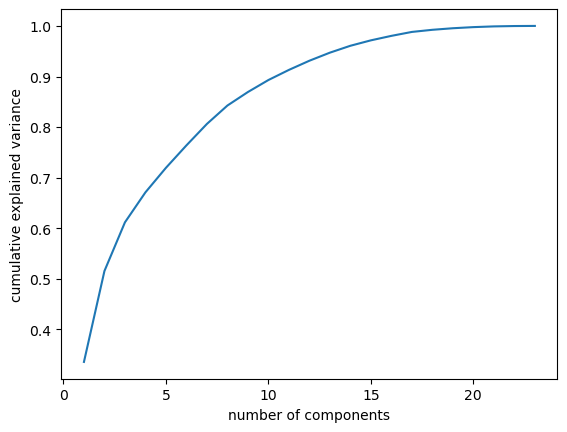

In [60]:
# plot
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

In [61]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
# convert to dataframe for easier plotting
x_pca = pd.DataFrame(x_pca,columns=['PC1','PC2'])
x_pca['price'] = df['price']
x_pca.head()

,PC1,PC2,price
0,-0.718003,-3.505142,13495.0
1,-0.718003,-3.505142,16500.0
2,0.366667,-2.279755,16500.0
3,-0.166498,-0.070601,13950.0
4,0.693468,-0.395555,17450.0


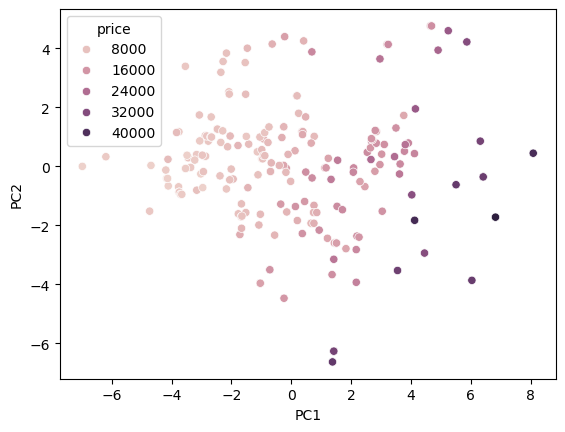

In [62]:
# plot reduced data
sns.scatterplot(data=x_pca,x='PC1',y='PC2',hue='price')
plt.show()

In [63]:
# feature matrix
x = x_pca[['PC1','PC2']]
# target variable(price)
y = x_pca['price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Hyperparameter Tuning

In [64]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 200, num = 10)]
# Number of features to consider at every split
max_features = ['sqrt', 'log2']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

# 4. Instantiate the RandomizedSearchCV model
# Search across 100 different combinations, using 3 fold cross validation, 
# and use all available cores
rf_model = RandomForestRegressor()
rf_random = RandomizedSearchCV(estimator = rf_model, param_distributions = random_grid, 
                               n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1,
                               scoring='neg_mean_squared_error') # Use a regression-specific scoring metric

# 5. Fit the random search model
rf_random.fit(X_train, y_train)

# 6. Print the best hyperparameters found
print(f"Best parameters found: {rf_random.best_params_}")

# 7. Evaluate the best model
best_rf = rf_random.best_estimator_
score = best_rf.score(X_test, y_test)
print(f"Test set R^2 score with best parameters: {score:.3f}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters found: {'n_estimators': 178, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Test set R^2 score with best parameters: 0.937


After Hyperparameter tuning using RandomizedSearchCV getting and R squared value of 93% accuracy.